In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import time
import copy
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cuda
PyTorch version: 2.10.0+cu126


In [2]:
BATCH_SIZE = 128

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = MNIST(root='data/', train=True,  download=True, transform=transform)
full_test  = MNIST(root='data/', train=False, download=True, transform=transform)

train_data, val_data = random_split(
    full_train, [42000, 18000],
    generator=torch.Generator().manual_seed(SEED)
)
val_data, test_data = random_split(
    val_data, [9000, 9000],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'Train samples:      {len(train_data):,}')
print(f'Validation samples: {len(val_data):,}')
print(f'Test samples:       {len(test_data):,}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 333kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]


Train samples:      42,000
Validation samples: 9,000
Test samples:       9,000


In [4]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches:      {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches:       {len(test_loader)}')

Train batches:      329
Validation batches: 71
Test batches:       71


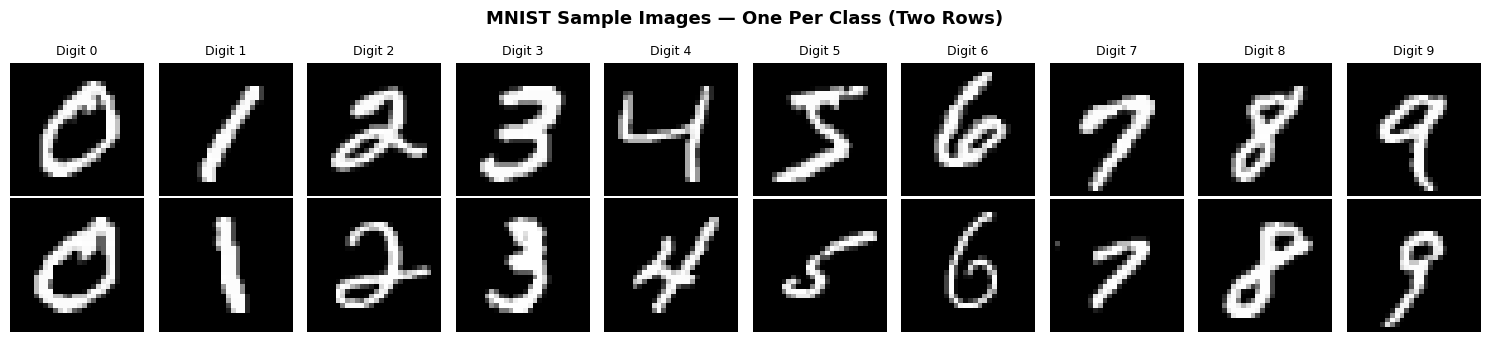

Fig 1: MNIST sample images — two instances per class.


In [5]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle('MNIST Sample Images — One Per Class (Two Rows)', fontsize=13, fontweight='bold')

class_samples = {i: [] for i in range(10)}
for img, label in full_train:
    if len(class_samples[label]) < 2:
        class_samples[label].append(img)
    if all(len(v) == 2 for v in class_samples.values()):
        break

for col, digit in enumerate(range(10)):
    for row in range(2):
        axes[row, col].imshow(class_samples[digit][row].squeeze(), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'Digit {digit}', fontsize=9)

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1: MNIST sample images — two instances per class.')

In [ ]:
class ModelA_Baseline(nn.Module):
  
    def __init__(self):
        super().__init__()
        self.conv1  = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool   = nn.MaxPool2d(2, 2)
        self.fc1    = nn.Linear(32 * 14 * 14, 128)
        self.fc2    = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   #  [B, 32, 14, 14]
        x = x.view(x.size(0), -1)              #  [B, 6272]
        x = F.relu(self.fc1(x))                #  [B, 128]
        return self.fc2(x)                     #  [B, 10]


class ModelB_Medium(nn.Module):
   
    def __init__(self):
        super().__init__()
        self.conv1  = nn.Conv2d(1,  32, kernel_size=3, padding=1)
        self.bn1    = nn.BatchNorm2d(32)
        self.conv2  = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2    = nn.BatchNorm2d(64)
        self.pool   = nn.MaxPool2d(2, 2)
        self.fc1    = nn.Linear(64 * 7 * 7, 256)
        self.bn3    = nn.BatchNorm1d(256)
        self.fc2    = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  #  [B, 32, 14, 14]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  #  [B, 64, 7, 7]
        x = x.view(x.size(0), -1)                       #  [B, 3136]
        x = F.relu(self.bn3(self.fc1(x)))               #  [B, 256]
        return self.fc2(x)                              #  [B, 10]



class ModelC_Deep(nn.Module):
    
    def __init__(self, dropout_rate=0.4):
        super().__init__()
      
        self.conv1a = nn.Conv2d(1,  32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)
       
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
      
        self.conv3  = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3    = nn.BatchNorm2d(128)
        
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout_rate)
     
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = self.pool(F.relu(self.bn1b(self.conv1b(x))))
       
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = self.pool(F.relu(self.bn2b(self.conv2b(x))))
      
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
       
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout(x)
        return self.fc2(x)

Model A (Baseline): 804,554 trainable parameters
Model B (Medium): 825,162 trainable parameters
Model C (Deep): 437,738 trainable parameters


In [ ]:
def train_model(model, train_loader, val_loader,
                n_epochs=25, lr=1e-3,
                patience=7, model_name='model'):
  
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3,
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(n_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds  = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d}/{n_epochs} | '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

        if no_improve >= patience:
            print(f'[{model_name}] Early stopping at epoch {epoch+1}.')
            break

    print(f'[{model_name}] Training complete. '
          f'Best val loss: {best_val_loss:.4f} | ')

    model.load_state_dict(best_state)  # restore best weights
    return history, model


def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)

In [11]:
model_a = ModelA_Baseline()
print(model_a)

ModelA_Baseline(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [12]:
history_a, model_a = train_model(
    model_a, train_loader, val_loader,
    n_epochs=25, lr=1e-3, patience=7,
    model_name='Model A (Baseline)'
)

acc_a, preds_a, labels_a = evaluate_model(model_a, test_loader)
print(f'\nModel A — Test Accuracy: {acc_a:.4f} ({acc_a*100:.2f}%)')

[Model A (Baseline)] Epoch   1/25 | Train Loss: 0.2268  Acc: 0.9332 | Val Loss: 0.0964  Acc: 0.9720 | Elapsed: 56s
[Model A (Baseline)] Epoch   5/25 | Train Loss: 0.0288  Acc: 0.9906 | Val Loss: 0.0625  Acc: 0.9818 | Elapsed: 343s
[Model A (Baseline)] Epoch  10/25 | Train Loss: 0.0101  Acc: 0.9969 | Val Loss: 0.0738  Acc: 0.9822 | Elapsed: 648s
[Model A (Baseline)] Epoch  15/25 | Train Loss: 0.0004  Acc: 1.0000 | Val Loss: 0.0555  Acc: 0.9874 | Elapsed: 904s
[Model A (Baseline)] Early stopping at epoch 19.
[Model A (Baseline)] Training complete. Best val loss: 0.0536 | Total time: 1118s

Model A — Test Accuracy: 0.9869 (98.69%)


In [13]:
model_b = ModelB_Medium()
print(model_b)

ModelB_Medium(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [14]:
history_b, model_b = train_model(
    model_b, train_loader, val_loader,
    n_epochs=25, lr=1e-3, patience=7,
    model_name='Model B (Medium)'
)

acc_b, preds_b, labels_b = evaluate_model(model_b, test_loader)
print(f'\nModel B — Test Accuracy: {acc_b:.4f} ({acc_b*100:.2f}%)')

[Model B (Medium)] Epoch   1/25 | Train Loss: 0.1162  Acc: 0.9682 | Val Loss: 0.0474  Acc: 0.9880 | Elapsed: 63s
[Model B (Medium)] Epoch   5/25 | Train Loss: 0.0088  Acc: 0.9977 | Val Loss: 0.0306  Acc: 0.9898 | Elapsed: 316s
[Model B (Medium)] Epoch  10/25 | Train Loss: 0.0024  Acc: 0.9993 | Val Loss: 0.0246  Acc: 0.9938 | Elapsed: 642s
[Model B (Medium)] Epoch  15/25 | Train Loss: 0.0003  Acc: 1.0000 | Val Loss: 0.0245  Acc: 0.9936 | Elapsed: 976s
[Model B (Medium)] Early stopping at epoch 18.
[Model B (Medium)] Training complete. Best val loss: 0.0239 | Total time: 1178s

Model B — Test Accuracy: 0.9920 (99.20%)


In [15]:
model_c = ModelC_Deep(dropout_rate=0.4)
print(model_c)

ModelC_Deep(
  (conv1a): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_f

In [16]:
history_c, model_c = train_model(
    model_c, train_loader, val_loader,
    n_epochs=25, lr=1e-3, patience=7,
    model_name='Model C (Deep)'
)

acc_c, preds_c, labels_c = evaluate_model(model_c, test_loader)
print(f'\nModel C — Test Accuracy: {acc_c:.4f} ({acc_c*100:.2f}%)')

[Model C (Deep)] Epoch   1/25 | Train Loss: 0.1651  Acc: 0.9584 | Val Loss: 0.0352  Acc: 0.9913 | Elapsed: 71s
[Model C (Deep)] Epoch   5/25 | Train Loss: 0.0255  Acc: 0.9918 | Val Loss: 0.0218  Acc: 0.9938 | Elapsed: 325s
[Model C (Deep)] Epoch  10/25 | Train Loss: 0.0169  Acc: 0.9944 | Val Loss: 0.0171  Acc: 0.9949 | Elapsed: 595s
[Model C (Deep)] Epoch  15/25 | Train Loss: 0.0088  Acc: 0.9972 | Val Loss: 0.0197  Acc: 0.9942 | Elapsed: 850s
[Model C (Deep)] Epoch  20/25 | Train Loss: 0.0033  Acc: 0.9990 | Val Loss: 0.0165  Acc: 0.9961 | Elapsed: 1076s
[Model C (Deep)] Epoch  25/25 | Train Loss: 0.0017  Acc: 0.9995 | Val Loss: 0.0173  Acc: 0.9960 | Elapsed: 1390s
[Model C (Deep)] Training complete. Best val loss: 0.0142 | Total time: 1390s

Model C — Test Accuracy: 0.9949 (99.49%)


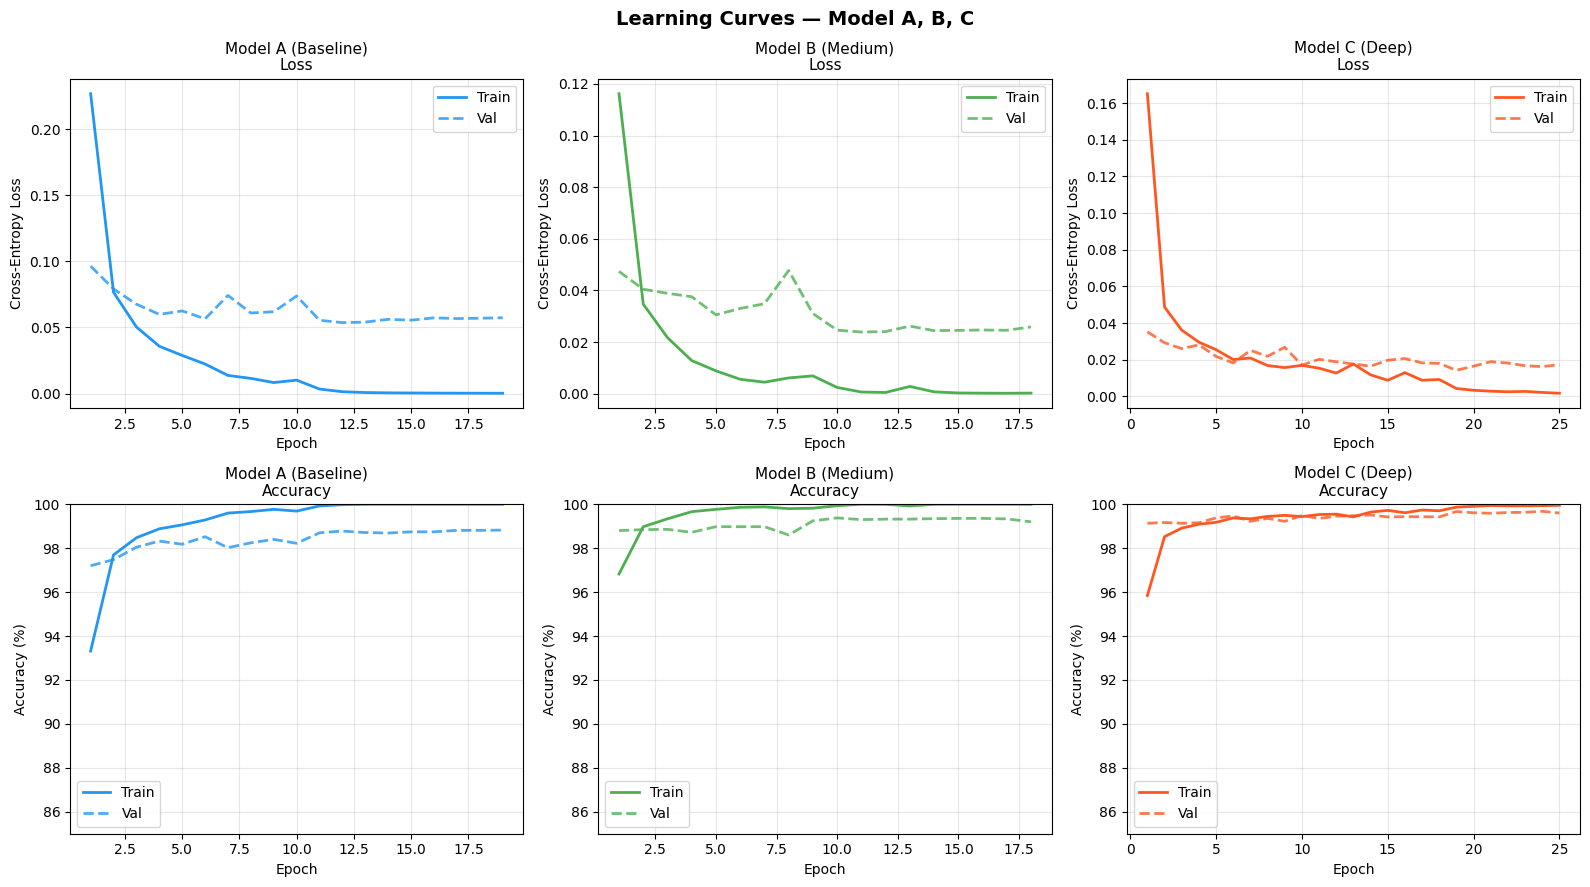

Fig 2: Learning curves (loss and accuracy) for all three models.


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Learning Curves — Model A, B, C', fontsize=14, fontweight='bold')

model_configs = [
    ('Model A (Baseline)',  history_a, '#2196F3'),
    ('Model B (Medium)',    history_b, '#4CAF50'),
    ('Model C (Deep)',      history_c, '#FF5722'),
]

for col, (name, hist, colour) in enumerate(model_configs):
    epochs = range(1, len(hist['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs, hist['train_loss'], color=colour,      label='Train', linewidth=2)
    axes[0, col].plot(epochs, hist['val_loss'],   color=colour, ls='--', label='Val',   linewidth=2, alpha=0.8)
    axes[0, col].set_title(f'{name}\nLoss', fontsize=11)
    axes[0, col].set_xlabel('Epoch');  axes[0, col].set_ylabel('Cross-Entropy Loss')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    # Accuracy
    axes[1, col].plot(epochs, [a*100 for a in hist['train_acc']], color=colour,      label='Train', linewidth=2)
    axes[1, col].plot(epochs, [a*100 for a in hist['val_acc']],   color=colour, ls='--', label='Val',   linewidth=2, alpha=0.8)
    axes[1, col].set_title(f'{name}\nAccuracy', fontsize=11)
    axes[1, col].set_xlabel('Epoch');  axes[1, col].set_ylabel('Accuracy (%)')
    axes[1, col].set_ylim([85, 100])
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2: Learning curves (loss and accuracy) for all three models.')

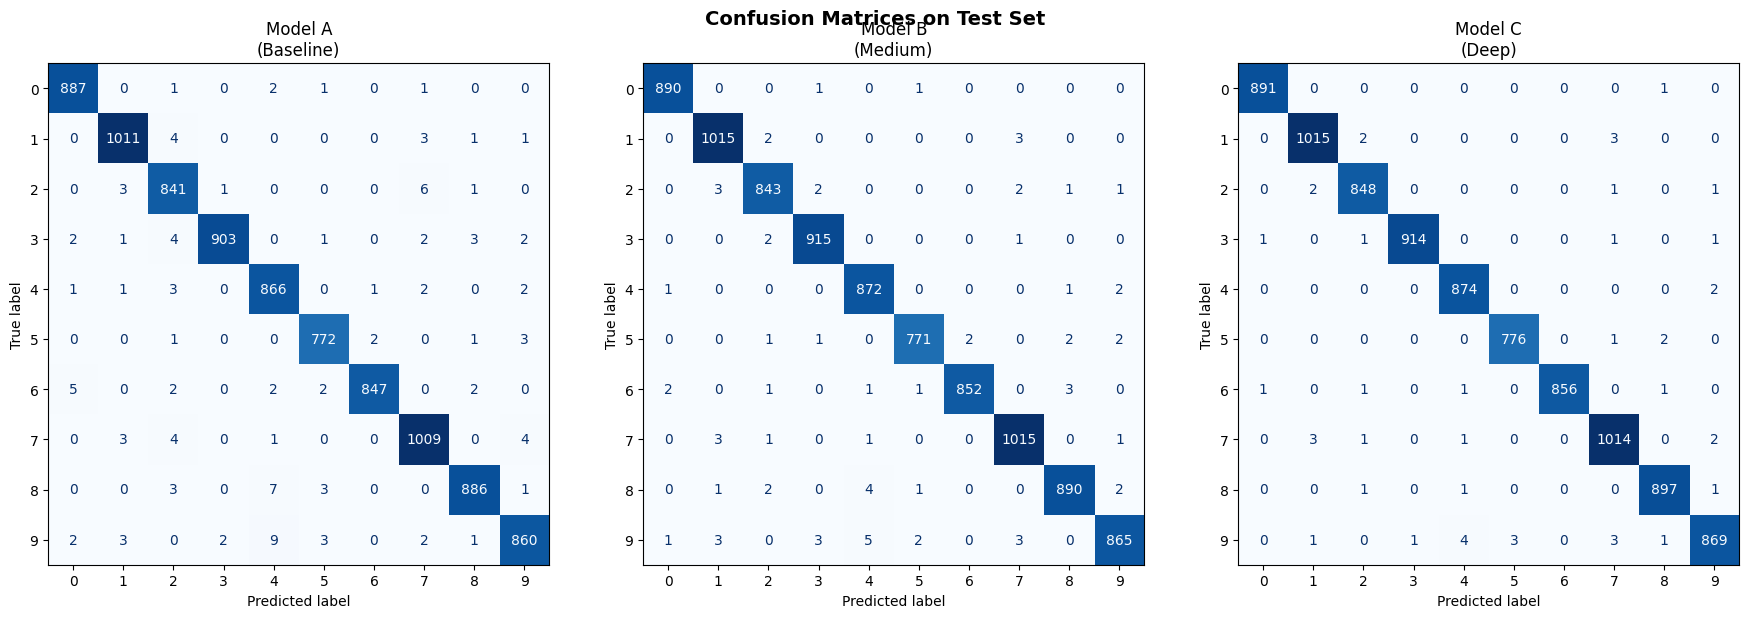

Fig 3: Confusion matrices for Models A, B, and C.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')

model_results = [
    ('Model A\n(Baseline)',  preds_a, labels_a),
    ('Model B\n(Medium)',    preds_b, labels_b),
    ('Model C\n(Deep)',      preds_c, labels_c),
]

for ax, (name, preds, labels) in zip(axes, model_results):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(range(10)))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3: Confusion matrices for Models A, B, and C.')

In [19]:
class_names = [str(i) for i in range(10)]

for name, preds, labels in [('Model A (Baseline)', preds_a, labels_a),
                              ('Model B (Medium)',   preds_b, labels_b),
                              ('Model C (Deep)',     preds_c, labels_c)]:
    print(f'\n{"─"*55}')
    print(f'  {name} — Classification Report')
    print(f'{"─"*55}')
    print(classification_report(labels, preds, target_names=class_names))


───────────────────────────────────────────────────────
  Model A (Baseline) — Classification Report
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       892
           1       0.99      0.99      0.99      1020
           2       0.97      0.99      0.98       852
           3       1.00      0.98      0.99       918
           4       0.98      0.99      0.98       876
           5       0.99      0.99      0.99       779
           6       1.00      0.98      0.99       860
           7       0.98      0.99      0.99      1021
           8       0.99      0.98      0.99       900
           9       0.99      0.98      0.98       882

    accuracy                           0.99      9000
   macro avg       0.99      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000


───────────────────────────────────────────────────────
  Model B (Medium) — Class

In [20]:
import pandas as pd

summary = pd.DataFrame({
    'Model':          ['A (Baseline)', 'B (Medium)', 'C (Deep)'],
    'Conv Blocks':    [1, 2, 3],
    'Batch Norm':     ['No', 'Yes', 'Yes'],
    'Dropout':        ['No', 'No', 'Yes (0.4)'],
    'Best Val Acc (%)': [
        round(max(history_a['val_acc']) * 100, 2),
        round(max(history_b['val_acc']) * 100, 2),
        round(max(history_c['val_acc']) * 100, 2),
    ],
    'Test Acc (%)':   [round(acc_a*100, 2), round(acc_b*100, 2), round(acc_c*100, 2)],
    'Epochs Trained': [
        len(history_a['train_loss']),
        len(history_b['train_loss']),
        len(history_c['train_loss']),
    ]
})

print('\n=== Summary Comparison Table ===')
print(summary.to_string(index=False))


=== Summary Comparison Table ===
       Model  Conv Blocks Batch Norm   Dropout  Best Val Acc (%)  Test Acc (%)  Epochs Trained
A (Baseline)            1         No        No             98.82         98.69              19
  B (Medium)            2        Yes        No             99.38         99.20              18
    C (Deep)            3        Yes Yes (0.4)             99.68         99.49              25
